QUESTION: ACME Insurance Inc. offers affordable health insurance to thousands of customer all over the 
United States. As the lead data scientist at ACME, you're tasked with creating an automated system to 
estimate the annual medical expenditure for new customers, using information such as their age, sex, BMI, 
children, smoking habits and region of residence.

Estimates from your system will be used to determine the annual insurance premium (amount paid every month) 
offered to the customer. Due to regulatory requirements, you must be able to explain why your system outputs
a certain prediction.

You're given a CSV file containing verified historical data, consisting of the mentioned information and the
actual medical charges incurred by over 1300 customers.

In [1]:
import pandas as pd
medical_df=pd.read_csv("Datasets\insurance.csv")
medical_df

<>:2: SyntaxWarning: invalid escape sequence '\i'
<>:2: SyntaxWarning: invalid escape sequence '\i'
C:\Users\HP\AppData\Local\Temp\ipykernel_8268\1047449081.py:2: SyntaxWarning: invalid escape sequence '\i'
  medical_df=pd.read_csv("Datasets\insurance.csv")


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [2]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [3]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [4]:
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
sns.set_style("darkgrid")

AGE

In [6]:
medical_df['age'].describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

In [7]:
fig=px.histogram(
    medical_df,
    x='age',
    marginal='box',
    nbins=47,
    title='Age distribution'
)
fig.update_layout(bargap=0.1)
fig.show()

The distribution of ages in the dataset is almost uniform, with 20–30 customers at every age, except for the ages 18 and 19, which seem to have over twice as many customers as other ages. The uniform distribution might arise from the fact that there isn't a big variation in the number of people of any given age (between 18 & 64) in the USA.

BMI

In [8]:
fig=px.histogram(
    medical_df,
    x='bmi',
    marginal='box',
    color_discrete_sequence=['red'],
    title='BMI distribution'
)
fig.update_layout(bargap=0.1)
fig.show()

The measurements of body mass index seem to form a Gaussian distribution centered around the value 30, with a few outliers towards the right.

CHARGES

In [9]:
fig=px.histogram(
    medical_df,
    x='charges',
    marginal='box',
    color='smoker',
    color_discrete_sequence=['red','green'],
    title='Charges distribution'
)
fig.update_layout(bargap=0.1)
fig.show()

-> For most customers, the annual medical charges are under $10,000. Only a small fraction of customer have higher medical expenses, possibly due to accidents, major illnesses and genetic diseases. The distribution follows a "power law".

-> There is a significant difference in medical expenses between smokers and non-smokers. While the median for non-smokers is $7,300, the median for smokers is close to $35,000.

SMOKERS

In [10]:
medical_df['smoker'].value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [11]:
px.histogram(medical_df,x='smoker',color='sex',title='smoker')

Age vs Charges

In [12]:
fig=px.scatter(
    medical_df,
    x='age',
    y='charges',
    color='smoker',
    hover_data='sex',
    opacity=0.8,
    title="Age vs Charges"
)
fig.update_traces(marker_size=5)
fig.show()

-> We can see three "clusters" of points, each of which seems to form a line with an increasing slope:

1] The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others.
2] The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues" and "smokers without major medical issues".
3] The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.

BMI vs CHARGES

In [13]:
fig=px.scatter(
    medical_df,
    x='bmi',
    y='charges',
    color='smoker',
    opacity=0.6,
    hover_data=['sex'],
    title='BMI vs CHARGES'
)
fig.update_traces(marker_size=5)
fig.show()

Correlation

As you can tell from the analysis, the values in some columns are more closely related to the values in "charges" compared to other columns. E.g. "age" and "charges" seem to grow together, whereas "bmi" and "charges" don't.

This relationship is often expressed numerically using a measure called the correlation coefficient, which can be computed using the .corr method of a Pandas serie

In [14]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306476)

In [15]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362878)

In [24]:
medical_df.sex

0       female
1         male
2         male
3         male
4         male
         ...  
1333      male
1334    female
1335    female
1336    female
1337    female
Name: sex, Length: 1338, dtype: object

In [21]:
gender_values={'male' : 0, 'female':1}
gender_numeric=medical_df.sex.map(gender_values)
gender_numeric

0       1
1       0
2       0
3       0
4       0
       ..
1333    0
1334    1
1335    1
1336    1
1337    1
Name: sex, Length: 1338, dtype: int64

In [25]:
medical_df.charges.corr(gender_numeric)

np.float64(-0.057292062202025346)

In [29]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


Text(0.5, 1.0, 'correlation matrix')

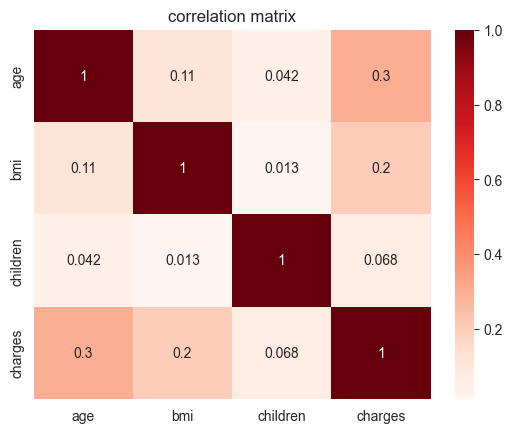

In [31]:
sns.heatmap(medical_df.corr(numeric_only=True),annot=True,cmap="Reds")
plt.title("correlation matrix")

Linear Regression between single Feature

In [32]:
non_smoker_df=medical_df[medical_df.smoker=='no']

<Axes: title={'center': 'age vs charges'}, xlabel='age', ylabel='charges'>

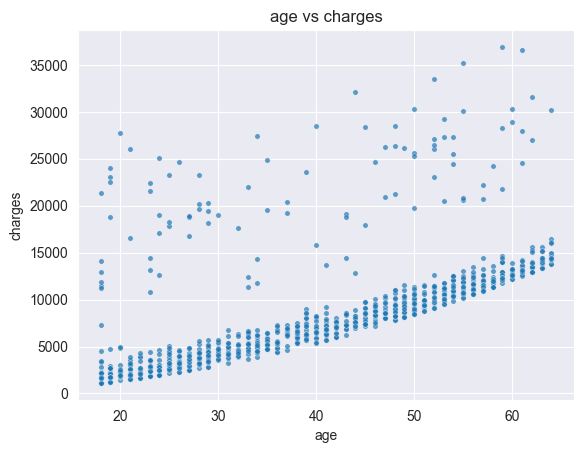

In [36]:
plt.title("age vs charges")
sns.scatterplot(data=non_smoker_df,x='age',y='charges',alpha=0.7,s=15)


following formula:

y=wx + b

The line is characterized two numbers: w (called "slope") and b (called "intercept").

Model

In the above case, the x axis shows "age" and the y axis shows "charges". Thus, we're assume the following relationship between the two:

charges= w × age + b

We'll try determine w and b for the line that best fits the data.

-> This technique is called linear regression, and we call the above equation a linear regression model, because it models the relationship between "age" and "charges" as a straight line.
-> The numbers w and b are called the parameters or weights of the model.
-> The values in the "age" column of the dataset are called the inputs to the model and the values in the charges column are called "targets".

In [ ]:
def estimate_charges(age,w,b):
    return w*age+b